# Visualizing the Training Loop

we wrote the script in train.py that forces the PyTorch `Autograd` engine to backpropagate mathematically through physical radio noise.

In this notebook, we run a rapid, miniaturized version of that exact training loop to visualize the Loss Curve dropping over time. This mathematically proves that our AI is learning to create distinct, safe distance boundaries between semantic concepts to protect them from noise.

In [1]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.model import JointSemanticModel

print("loaded.")

loaded.


### Setting up the Mini-Training Loop
We will use a tiny vocabulary and a single batch of random data, and train it for 50 epochs at 10 dB SNR.

In [ ]:
vocab_size = 50
model = JointSemanticModel(vocab_size=vocab_size, embed_dim=32, hidden_dim=64, snr_db=10.0)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss() # Ignoring PAD for this tiny demo is fine

# A batch of 100 random sentences, length 15
torch.manual_seed(42)
dummy_data = torch.randint(1, vocab_size, (100, 15))

epochs = 50
loss_history = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(dummy_data, dummy_data)
    
    # Flatten outputs for CrossEntropy
    outputs_flat = outputs[:, :-1, :].reshape(-1, vocab_size)
    targets_flat = dummy_data[:, 1:].reshape(-1)
    
    loss = criterion(outputs_flat, targets_flat)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
print("Done")

Done


### Visualizing the Loss Curve
If the JSCC network successfully learns to combat the AWGN noise, the loss should drop in a smooth curve, proving that the gradients are successfully penetrating the noise layer.

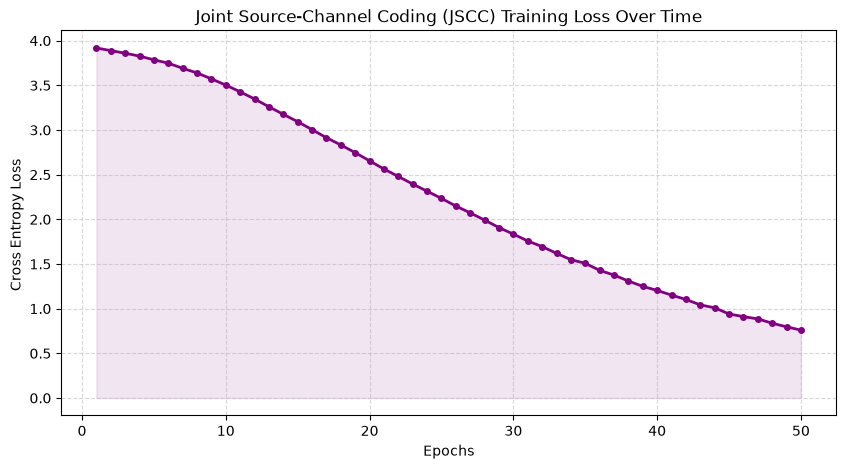

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), loss_history, marker='o', color='purple', linewidth=2, markersize=4)
plt.title("Joint Source-Channel Coding (JSCC) Training Loss Over Time")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss ")
plt.grid(True, linestyle='--', alpha=0.5)
plt.fill_between(range(1, epochs+1), loss_history, color='purple', alpha=0.1)
plt.show()